In [1]:
import gaiaDR4_pipeline as gp
from pathlib import Path
from tqdm import tqdm 
import os
import torch
torch.set_num_threads(1) 
torch.set_num_interop_threads(1)
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Set output directory

In [2]:
cwd = Path(os.getcwd()) / "dr4_prerelease"

# Read in DR4 prerelease data

In [3]:
table = Table.read(cwd / "GAIA_DR4_PRERELEASE_EPOCH_ASTROMETRY_RAW.xml", format="votable")
df_data = table.to_pandas()

# Target List

In [2]:
source_ids = [ 1457486023639239296,  3937211745905473024] # Gaia-4, HD 114762

# Run grid search on all targets

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

for source_id in tqdm(source_ids):
    t_binned, psi_binned, w_binned, sig_w_binned, pf_binned = gp.utils.extract_time_series(source_id, df_data)
    gp.grid.run_grid_search(cwd, source_id, t_binned, psi_binned, pf_binned, w_binned, sig_w_binned, 
                                  device=device, N_logP=300, N_ecc=10, N_phi=10, P_range=[10,1e4]) # resolution kept low for demonstration

cpu


100%|██████████| 2/2 [00:09<00:00,  4.99s/it]


# Plot $\chi^2$ vs. log of period

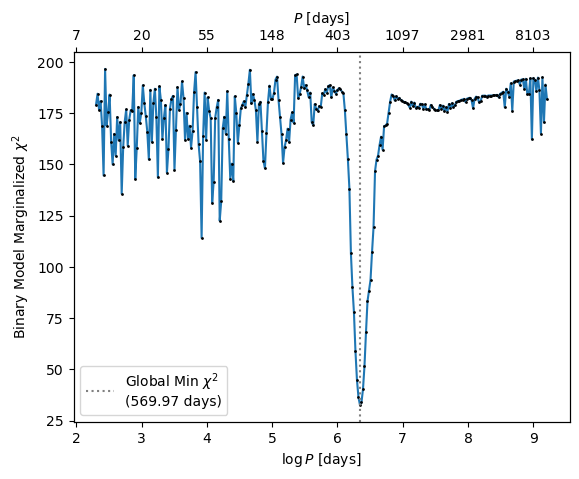

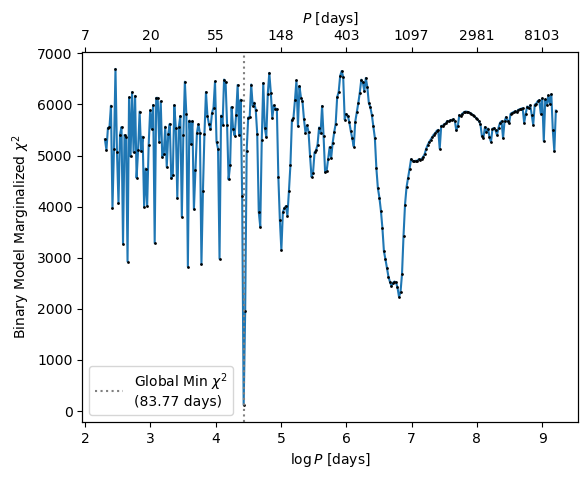

In [6]:
for source_id in source_ids:
    gp.plotting.plot_grid_search_chi2(cwd, source_id)
    plt.show()